# E-commerce Data Analysis - SQL + Python

**Author:** Rishav Raj   
**Project:** E-Commerce Sales & Customer Analytics (SQL + Python)    
**Dataset:** [Olist Brazilian E-Commerce – Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)   

This project looks at customer behavior, sales trends, and delivery performance using Olist's e-commerce data, a Brazilian online marketplace. The dataset has around 100,000 orders placed between 2016 and 2018, and I used it to explore things like which categories sell the most, how payment installments affect order value, how fast deliveries are across different states, and how often customers come back to buy again.

# Imports

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import mysql.connector

# Loading data into MySQL server 

In [6]:
# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),     # Added payments.csv for specific handling
    ('order_items.csv', 'order_items')
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = '/Users/rishavraj/Desktop/ecommerce'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
prod

In [7]:
db = mysql.connector.connect(host = "localhost",
                            username = "root",
                            password = "",
                            database = "ecommerce")
cur = db.cursor()

## 1. Top 10 most frequently purchased products

In [8]:
query = """SELECT oi.product_id, p.product_category_name,
 COUNT(oi.product_id) AS freq_purchased
FROM order_items oi
JOIN products p ON p.product_id = oi.product_id
GROUP BY oi.product_id, p.product_category_name
ORDER BY freq_purchased DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ['product_id','product_category','freq_purchased'])
df

,product_id,product_category,freq_purchased
0,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,4743
1,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,4392
2,422879e10f46682990de24d770e7f83d,ferramentas_jardim,4356
3,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,3528
4,368c6c730842d78016ad823897a372db,ferramentas_jardim,3492
5,53759a2ecddad2bb87a079a1f1519f73,ferramentas_jardim,3357
6,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,3087
7,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,2907
8,154e7e31ebfa092203795c972e5804a6,beleza_saude,2529
9,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,2466


## 2. Number of sellers per state

In [12]:
query = """SELECT seller_state,
 COUNT(DISTINCT seller_id) AS num_sellers
FROM sellers
GROUP BY seller_state
ORDER BY num_sellers DESC;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ['seller_state','num_sellers'])
df

,seller_state,num_sellers
0,SP,1849
1,PR,349
2,MG,244
3,SC,190
4,RJ,171
5,RS,129
6,GO,40
7,DF,30
8,ES,23
9,BA,19


## 3. Number of products per category

In [71]:
query = """SELECT product_category_name,
 COUNT(*) AS total_products
FROM products
WHERE product_category_name IS NOT NULL
GROUP BY product_category_name
ORDER BY total_products DESC;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["product_category", "total_products"])
df

,product_category,total_products
0,cama_mesa_banho,3029
1,esporte_lazer,2867
2,moveis_decoracao,2657
3,beleza_saude,2444
4,utilidades_domesticas,2335
...,...,...
68,fashion_roupa_infanto_juvenil,5
69,casa_conforto_2,5
70,pc_gamer,3
71,seguros_e_servicos,2


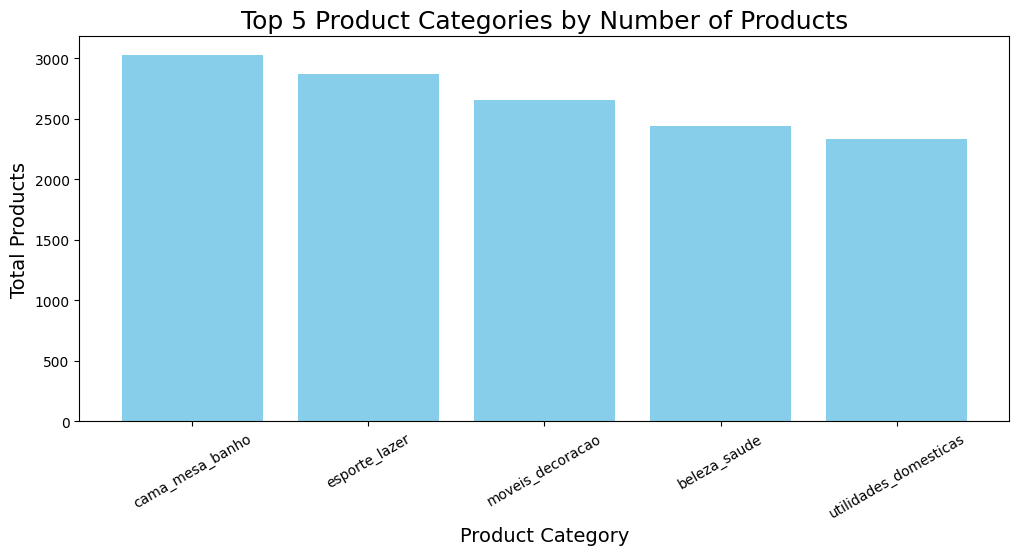

In [72]:
df = df.head(5)
plt.figure(figsize=(12,5))
plt.bar(df['product_category'], df['total_products'], color='skyblue')
plt.title('Top 5 Product Categories by Number of Products', fontsize = 18)
plt.xlabel('Product Category',fontsize = 14)
plt.ylabel('Total Products',fontsize = 14)
plt.xticks(rotation=30)
plt.show()

## 4. Total sales per category

In [73]:
query = """-- I have included shipping cost as well.
SELECT p.product_category_name AS product_category, ROUND(SUM(oi.price + oi.freight_value),2) AS category_sales
FROM products p
JOIN order_items oi ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY category_sales DESC;
"""


cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["product_category", "category_sales"])
df

,product_category,category_sales
0,beleza_saude,1441248.07
1,relogios_presentes,1305541.61
2,cama_mesa_banho,1241681.72
3,esporte_lazer,1156656.48
4,informatica_acessorios,1059272.40
...,...,...
69,flores,1598.91
70,casa_conforto_2,1170.58
71,cds_dvds_musicais,954.99
72,fashion_roupa_infanto_juvenil,665.36


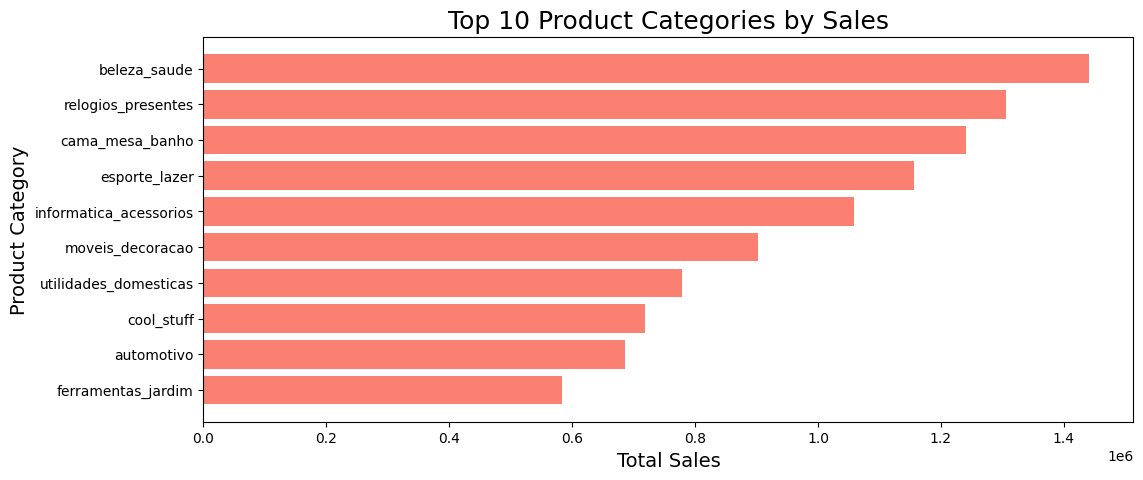

In [74]:
top10_sales_df = df.head(10)

# Horizontal bar plot
plt.figure(figsize=(12,5))
plt.barh(top10_sales_df['product_category'], top10_sales_df['category_sales'], color='salmon')
plt.title('Top 10 Product Categories by Sales', fontsize = 18)
plt.xlabel('Total Sales', fontsize = 14)
plt.ylabel('Product Category', fontsize = 14)
plt.gca().invert_yaxis()  # highest value on top
plt.show()

## 5. Percentage of orders paid in installments

In [20]:
query = """SELECT
COUNT((CASE WHEN payment_installments > 1 THEN order_id END))*100/COUNT(*) AS perc_of_installment_orders
FROM payments;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["perc_of_installment_orders" ])
df

,perc_of_installment_orders
0,49.4176


## 6. Average delivery time by state

In [25]:
query = """SELECT c.customer_state,
 AVG(datediff(o.order_delivered_customer_date, o.order_purchase_timestamp)) AS avg_delivery_time_days
FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_time_days;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_state", "avg_delivery_time_days"])
df

,customer_state,avg_delivery_time_days
0,SP,8.7005
1,PR,11.9380
2,MG,11.9465
3,DF,12.8990
4,SC,14.9075
5,RJ,15.2377
6,RS,15.2485
7,GO,15.5360
8,MS,15.5449
9,ES,15.7238


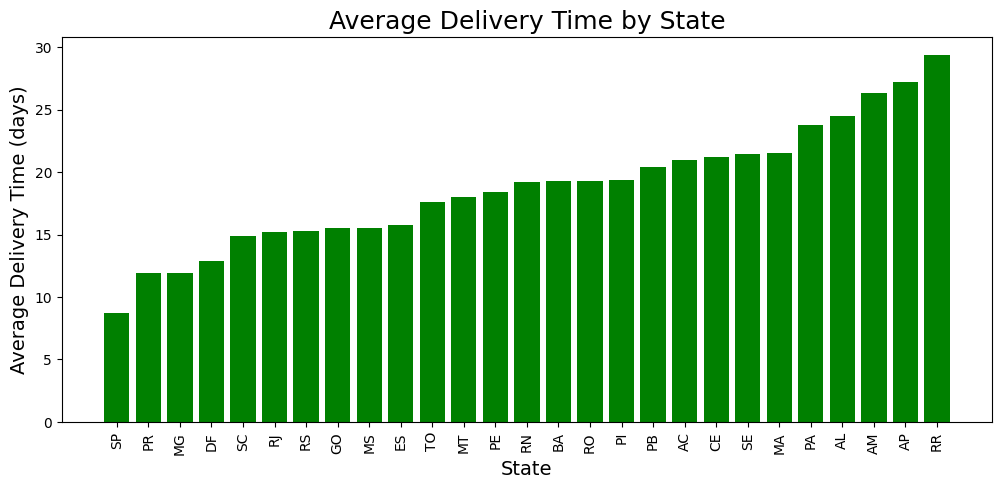

In [22]:
plt.figure(figsize=(12,5))
plt.bar(df['customer_state'], df['avg_delivery_time_days'], color='green')
plt.title('Average Delivery Time by State', fontsize = 18)
plt.xlabel('State', fontsize = 14)
plt.ylabel('Average Delivery Time (days)', fontsize = 14)
plt.xticks(rotation=90)
plt.show()

## 7. Top 5 product categories with highest return rate

#### To get different order status to decide which comes under returns.

In [23]:
query = """-- To get different order status to decide which comes under returns.
SELECT DISTINCT order_status,
 COUNT(*) AS num_orders
FROM orders
GROUP BY order_status;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["order_status", "num_orders"])
df

,order_status,num_orders
0,delivered,96478
1,invoiced,314
2,shipped,1107
3,processing,301
4,unavailable,609
5,canceled,625
6,created,5
7,approved,2


#### For this analysis, assuming all order status other than delivered as returns/not delivered.

In [11]:
query = """-- For this analysis, assuming all order status other than delivered as returns/not delivered.
SELECT p.product_category_name AS top_return_product_category,
 CONCAT(ROUND(COUNT(CASE WHEN o.order_status <> 'delivered' THEN 1 END)*100/ COUNT(*),2),'%') AS return_rate
FROM products p
JOIN order_items oi ON oi.product_id = p.product_id
JOIN orders o ON o.order_id = oi.order_id
WHERE p.product_category_name IS NOT NULL
GROUP BY p.product_category_name
ORDER BY COUNT(CASE WHEN o.order_status <> 'delivered' THEN 1 END)/ COUNT(*) DESC -- need for this instead return_rate in ORDER BY is because with concat of % retun_rate becomes string and hence sorts incorrectly
LIMIT 5;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["top_return_product_category", "return_rate"])
df

,top_return_product_category,return_rate
0,fashion_roupa_infanto_juvenil,12.50%
1,pc_gamer,11.11%
2,portateis_cozinha_e_preparadores_de_alimentos,6.67%
3,fashion_roupa_feminina,6.25%
4,artes,5.74%


### Pie Chart for this

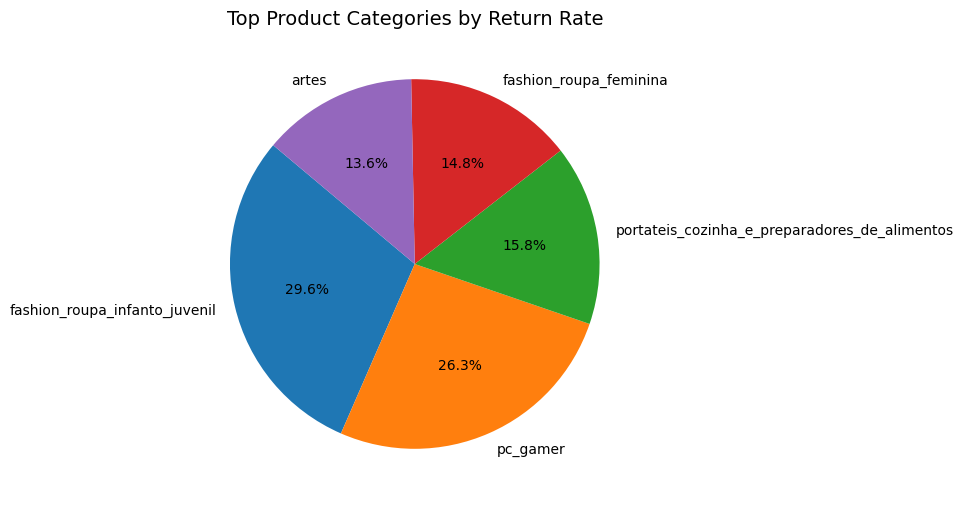

In [78]:
# Convert return_rate to numeric
df['return_rate_numeric'] = df['return_rate'].str.rstrip('%').astype(float)

# Pie chart
plt.figure(figsize=(10,6))
plt.pie(
    df['return_rate_numeric'], 
    labels=df['top_return_product_category'],
    textprops={'fontsize': 10},
    autopct='%1.1f%%', 
    startangle=140
)
plt.title('Top Product Categories by Return Rate', fontsize = 14)
plt.show()

## 8. Relationship between installment payments and order value

In [14]:
query = """WITH order_payments AS (
 SELECT order_id,
 -- Handling 2 outlier rows with '0' installments and treating them as '1'
 CASE WHEN MAX(payment_installments) = 0 THEN 1
 ELSE MAX(payment_installments)
 END AS installments,
 SUM(payment_value) AS total_payment
 FROM payments
 GROUP BY order_id
)
SELECT installments,
 ROUND(AVG(total_payment), 2) AS avg_order_value,
 COUNT(order_id) AS 'num_orders'
FROM order_payments
GROUP BY installments
ORDER BY installments;
"""


cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["installments", "avg_order_value","num_orders"])
print("Handling 2 outlier rows with '0' installments and treating them as '1' installment")
print(" ")
df

Handling 2 outlier rows with '0' installments and treating them as '1' installment
 


,installments,avg_order_value,num_orders
0,1,363.11,48270
1,2,387.37,12363
2,3,433.09,10429
3,4,495.18,7070
4,5,554.67,5227
5,6,634.78,3908
6,7,568.01,1622
7,8,929.32,4251
8,9,613.74,644
9,10,1256.24,5315


### Calculating correlation coefficient for the same.

In [15]:
import numpy as np
arr1 = df["installments"]
arr2 = df["avg_order_value"]

a = np.corrcoef([arr1,arr2])
print(f"The correlation coefficient is \033[1m{round(a[0][-1],3)}\033[0m." )

The correlation coefficient is 0.57.


- Hence it can be said that there exists a **moderate positive** correlation between average order value and number of installments.

## 9. Correlation between product price and purchase frequency

In [17]:
query = """select p.product_category_name,
count(order_items.product_id),
round( avg(order_items.price),2)
from products p 
join order_items
on p.product_id = order_items.product_id
group by p.product_category_name"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["product category", "order_count", "price"])

arr1 = df["order_count"]
arr2 = df["price"]

a = np.corrcoef([arr1,arr2])
print("The correlation between price and number of times a product has been purchased is", a[0][1])

The correlation between price and number of times a product has been purchased is -0.10631514167157564


## 10. Average number of products per order by customer state

In [32]:
query = """WITH state_order_items AS (
 SELECT c.customer_state, oi.order_id,
 COUNT(*) AS num_items
 FROM order_items oi
 JOIN orders o ON o.order_id = oi.order_id
 JOIN customers c ON c.customer_id = o.customer_id
 GROUP BY c.customer_state, oi.order_id
)
SELECT customer_state,
 AVG(num_items) AS avg_items_per_order
FROM state_order_items
GROUP BY customer_state
ORDER BY avg_items_per_order DESC;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["customer_state", "avg_items_per_order"])
df.head(10)

,customer_state,avg_items_per_order
0,AP,1.2059
1,MT,1.1683
2,GO,1.1624
3,SC,1.1561
4,MS,1.1551
5,PR,1.1485
6,RS,1.1478
7,SP,1.1468
8,RJ,1.1424
9,MG,1.1373


## 11. Percentage of revenue contributed by each product category

In [31]:
query = """SELECT p.product_category_name,
 ROUND(SUM(oi.price)*100/(SELECT SUM(price) FROM order_items),2) AS perc_contribution_in_sales
FROM order_items oi
JOIN products p ON p.product_id = oi.product_id
WHERE p.product_category_name IS NOT NULL
GROUP BY p.product_category_name
ORDER BY perc_contribution_in_sales DESC;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["product_category", "perc_contribution_in_sales"])
df

,product_category,perc_contribution_in_sales
0,beleza_saude,27.78
1,relogios_presentes,26.60
2,cama_mesa_banho,22.89
3,esporte_lazer,21.81
4,informatica_acessorios,20.13
...,...,...
68,flores,0.02
69,casa_conforto_2,0.02
70,cds_dvds_musicais,0.02
71,fashion_roupa_infanto_juvenil,0.01


### Bar Chart for top 20 categories

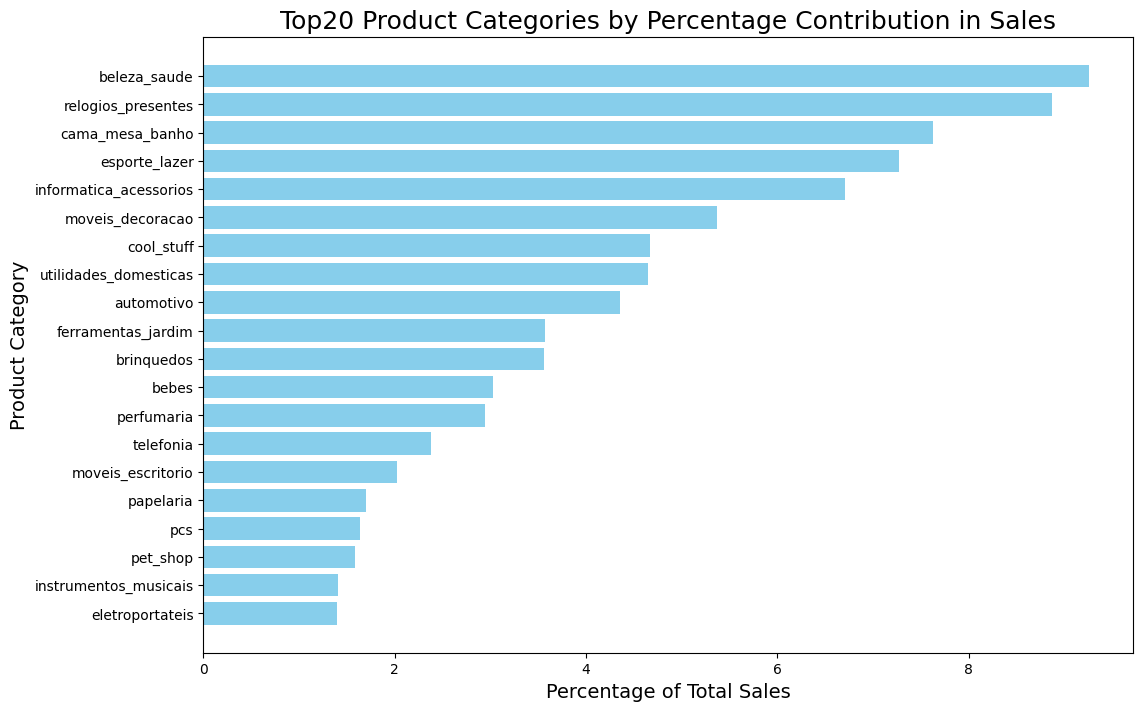

In [35]:
df = df.dropna(subset=['product_category'])
df = df.head(20)
plt.figure(figsize=(12,8))
plt.barh(df['product_category'], df['perc_contribution_in_sales'], color='skyblue')
plt.title('Top20 Product Categories by Percentage Contribution in Sales', fontsize = 18)
plt.xlabel('Percentage of Total Sales', fontsize = 14)
plt.ylabel('Product Category', fontsize = 14)
plt.gca().invert_yaxis()
plt.show()

## 12. Distribute orders across spend tiers (Very Low, Low, Medium, High, Very High)

#### Let's create a grouped frequency distribution table first to get appropriate spending groups

In [36]:
#To handle error: Expression #1 of SELECT list is not in GROUP BY clause and contains nonaggregated column
query1 = """SET SESSION sql_mode = (SELECT REPLACE(@@sql_mode,'ONLY_FULL_GROUP_BY',''));
"""
cur.execute(query1)
data = cur.fetchall()

In [37]:
query = """WITH order_totals AS (
 SELECT o.order_id,
 SUM(p.payment_value) AS total_order_value
 FROM orders o
 JOIN payments p ON o.order_id = p.order_id
 WHERE o.order_status = 'delivered'
 GROUP BY o.order_id
)
SELECT
 CONCAT(FLOOR(total_order_value/100)*100, '-',
FLOOR(total_order_value/100)*100 + 99) AS value_range,
 COUNT(*) AS order_count
FROM order_totals
GROUP BY FLOOR(total_order_value/100)
ORDER BY FLOOR(total_order_value/100)
;
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["value_range", "order_count"])
df

,value_range,order_count
0,0-99,45917
1,100-199,31018
2,200-299,9637
3,300-399,4073
4,400-499,1756
5,500-599,996
6,600-699,825
7,700-799,490
8,800-899,409
9,900-999,249


#### On basis of above table clustering orders into 5 tiers as :- 

In [38]:
query = """WITH order_totals AS (
 SELECT o.order_id,
 SUM(p.payment_value) AS total_order_value
 FROM orders o
 JOIN payments p ON o.order_id = p.order_id
 WHERE o.order_status = 'delivered'
 GROUP BY o.order_id
),
order_tiers AS (
 SELECT order_id,
 CASE
 WHEN total_order_value < 50 THEN 'Very Low'
 WHEN total_order_value BETWEEN 50 AND 100 THEN 'Low'
 WHEN total_order_value BETWEEN 100 AND 300 THEN 'Medium'
 WHEN total_order_value BETWEEN 300 AND 500 THEN 'High'  ELSE 'Very High'
 END AS spend_tier
 FROM order_totals
)
SELECT spend_tier,
 COUNT(*) AS order_count,
 CONCAT(ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2),'%') AS percentage_distribution
FROM order_tiers
GROUP BY spend_tier
ORDER BY -- custom sorting
 CASE spend_tier
 WHEN 'Very Low' THEN 1
 WHEN 'Low' THEN 2
 WHEN 'Medium' THEN 3
 WHEN 'High' THEN 4
 WHEN 'Very High' THEN 5
 END;
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["spend_tier", "order_count","percentage_distribution"])
df

,spend_tier,order_count,percentage_distribution
0,Very Low,16451,17.05%
1,Low,29469,30.55%
2,Medium,40652,42.14%
3,High,5829,6.04%
4,Very High,4076,4.22%


### Treemap for same

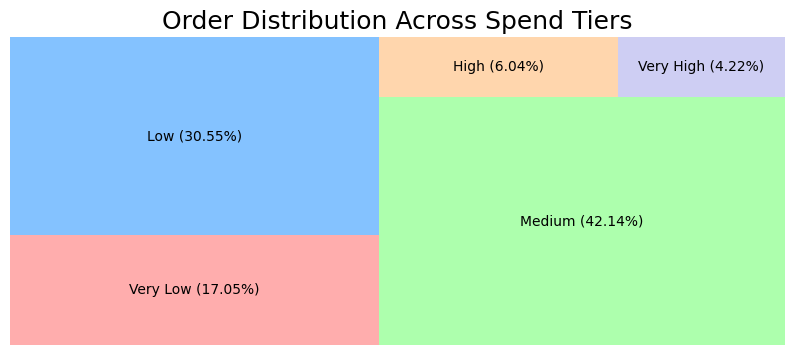

In [41]:
# Convert percentage strings to numeric
df['percentage_numeric'] = df['percentage_distribution'].str.rstrip('%').astype(float)

# Treemap
plt.figure(figsize=(10,4))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']  # custom colors
import squarify
squarify.plot(
    sizes=df['percentage_numeric'],
    label=df['spend_tier'] + ' (' + df['percentage_distribution'] + ')',
    color=colors,
    alpha=0.8
)
plt.title('Order Distribution Across Spend Tiers', fontsize = 18)
plt.axis('off')  # remove axes for cleaner look
plt.show()

## 13. Top 5 sellers’ market share per category

In [43]:
query = """WITH seller_category_sales AS(
 SELECT p.product_category_name, oi.seller_id,
 ROUND(SUM(oi.price + oi.freight_value),2) AS seller_category_sale,  DENSE_RANK() OVER(PARTITION BY p.product_category_name ORDER BY SUM(oi.price + oi.freight_value) DESC) AS seller_rank
 FROM order_items oi
 JOIN products p ON p.product_id = oi.product_id
 WHERE p.product_category_name IS NOT NULL
 GROUP BY p.product_category_name, oi.seller_id
)
SELECT product_category_name, seller_id, seller_category_sale,
 seller_rank,
 ROUND(seller_category_sale*100/SUM(seller_category_sale) OVER(PARTITION BY product_category_name),2) AS market_share_perc
FROM seller_category_sales
WHERE seller_rank <= 5
ORDER BY product_category_name, seller_category_sale DESC;
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["product_category", "seller_id", "seller_category_sale","seller_rank","market_share_perc"])
df

,product_category,seller_id,seller_category_sale,seller_rank,market_share_perc
0,agro_industria_e_comercio,e59aa562b9f8076dd550fcddf0e73491,33803.97,1,54.38
1,agro_industria_e_comercio,6bd69102ab48df500790a8cecfc285c2,8359.02,2,13.45
2,agro_industria_e_comercio,f08a5b9dd6767129688d001acafc21e5,7796.21,3,12.54
3,agro_industria_e_comercio,2528744c5ef5d955adc318720a94d2e7,6508.70,4,10.47
4,agro_industria_e_comercio,31ae0774c17fabd06ff707cc5bde005f,5690.23,5,9.15
...,...,...,...,...,...
343,utilidades_domesticas,53e4c6e0f4312d4d2107a8c9cddf45cd,35781.67,1,27.65
344,utilidades_domesticas,955fee9216a65b617aa5c0531780ce60,35518.10,2,27.45
345,utilidades_domesticas,729f06993dac8e860d4f02d7088ca48a,20811.44,3,16.08
346,utilidades_domesticas,9de4643a8dbde634fe55621059d92273,18908.65,4,14.61


## 14. Top 3 highest-spending customers per year

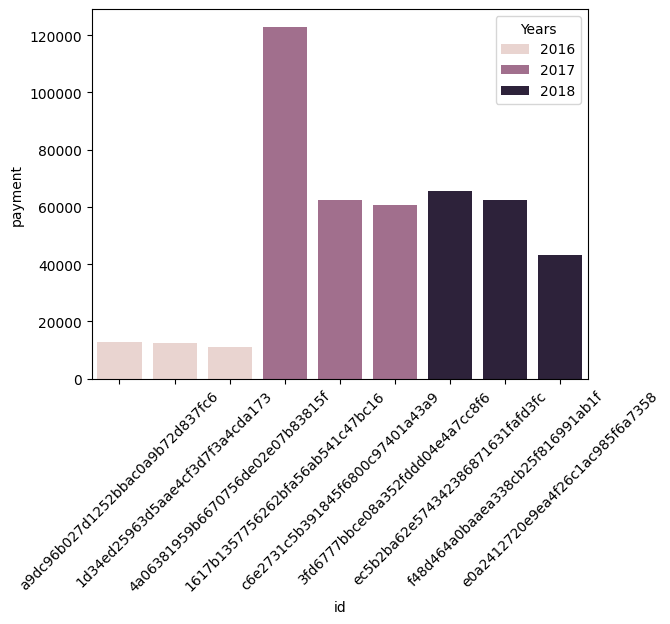

In [18]:
query  = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3 """

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns=["Years", "id", "payment", "rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "Years")
plt.xticks(rotation = 45)
plt.show()

## 15. Month-on-month growth rate of total sales

In [69]:
query = """WITH monthly_sales AS (
SELECT
 YEAR(o.order_purchase_timestamp) AS year,
 MONTH(o.order_purchase_timestamp) AS month_num,
 MONTHNAME(o.order_purchase_timestamp) AS month,
 ROUND(SUM(p.payment_value),2) AS monthly_sales
FROM orders o
JOIN payments p ON p.order_id = o.order_id
GROUP BY year, month_num, month
ORDER BY year, month_num
)
SELECT year, month, monthly_sales,
 LAG(monthly_sales,1) OVER(ORDER BY year, month_num) AS prev_month_sale,
 ROUND((monthly_sales - LAG(monthly_sales,1) OVER(ORDER BY year, month_num))*100/LAG(monthly_sales,1) OVER(ORDER BY year, month_num),2) AS  Mom_growth
 FROM monthly_sales;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["year", "month","monthly_sales","prev_month_sale","Mom_growth"])
df

,year,month,monthly_sales,prev_month_sale,Mom_growth
0,2016,September,252.24,NaN,NaN
1,2016,October,59090.48,252.24,23326.29
2,2016,December,19.62,59090.48,-99.97
3,2017,January,138488.04,19.62,705751.38
4,2017,February,291908.01,138488.04,110.78
5,2017,March,449863.60,291908.01,54.11
6,2017,April,417788.03,449863.60,-7.13
7,2017,May,592918.82,417788.03,41.92
8,2017,June,511276.38,592918.82,-13.77
9,2017,July,592382.92,511276.38,15.86


### A line chart for MoM Growth trend

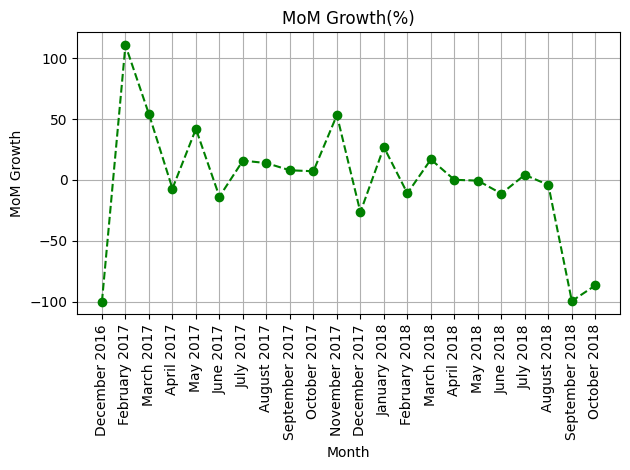

In [65]:
#attaching year and month first in dataframe as a combined column
df['month_label'] = df['month'] + ' ' + df['year'].astype(str)

# to exclude outliers, filtering the dataframe
filtered_df = df[df['Mom_growth'] <= 150].copy()

# Create combined month labels
filtered_df['month_label'] = filtered_df['month'] + ' ' + filtered_df['year'].astype(str)

plt.plot(filtered_df['month_label'], filtered_df['Mom_growth'], color='green', marker='o', linestyle='--')

plt.xlabel('Month')
plt.ylabel('MoM Growth')
plt.title('MoM Growth(%)')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

## 16. Year-over-year sales growth rate

In [29]:
query = """with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years order by years)

select years, ((payment - lag(payment, 1) over(order by years))/
lag(payment,1) over(order by years)) * 100 from a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["Years", "yoy % growth"])
df_clean = df[df["Years"] != 2016]
df_clean

,Years,yoy % growth
1,2017,12112.703758
2,2018,20.000924


## 17. Monthly order count for 2018

<function matplotlib.pyplot.show(close=None, block=None)>

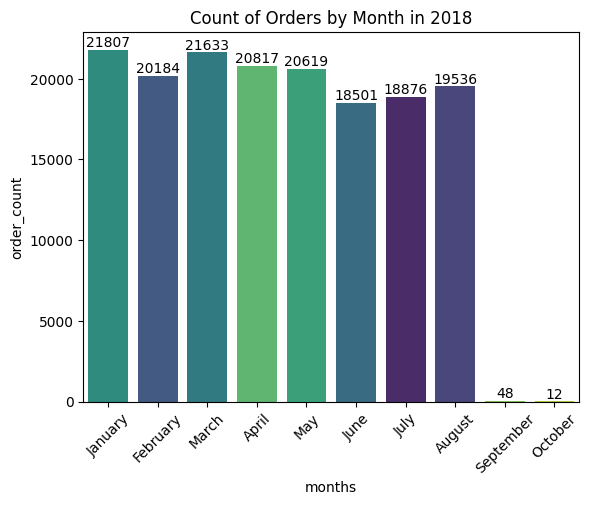

In [21]:
query = """select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October" ]

ax = sns.barplot(x = df["months"], y = df["order_count"], data = df, order = o, hue = df["months"], palette = "viridis")
plt.xticks(rotation = 45)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Count of Orders by Month in 2018")
plt.show

## 18. Cumulative sales per month per year

In [46]:
query = """WITH monthly_sales AS (
SELECT
 YEAR(o.order_purchase_timestamp) AS year,
 MONTH(o.order_purchase_timestamp) AS month_num,
 MONTHNAME(o.order_purchase_timestamp) AS month,
 ROUND(SUM(p.payment_value),2) AS monthly_sales
FROM orders o
JOIN payments p ON p.order_id = o.order_id
GROUP BY year, month_num, month
ORDER BY year, month_num
)
SELECT
 CONCAT(month,' ', year) AS Month,
 monthly_sales,
 ROUND(SUM(monthly_sales) OVER(PARTITION BY year ORDER BY month_num),2) AS monthly_cumulative_sales
FROM monthly_sales
ORDER BY year, month_num;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Month", "monthly_sales","monthly_cumulative_sales"])
df

,Month,monthly_sales,monthly_cumulative_sales
0,September 2016,252.24,252.24
1,October 2016,59090.48,59342.72
2,December 2016,19.62,59362.34
3,January 2017,138488.04,138488.04
4,February 2017,291908.01,430396.05
5,March 2017,449863.60,880259.65
6,April 2017,417788.03,1298047.68
7,May 2017,592918.82,1890966.50
8,June 2017,511276.38,2402242.88
9,July 2017,592382.92,2994625.80


### Dual Axis (on y-axis) Chart for cumulative sales

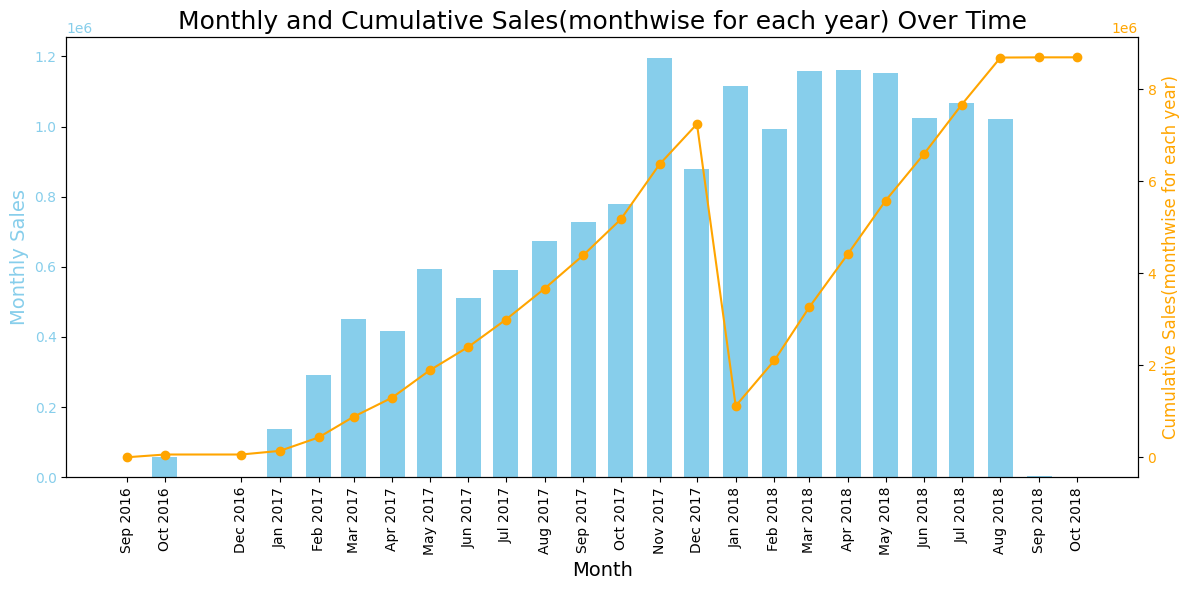

In [47]:
# Convert 'Month' to datetime
df['Month_dt'] = pd.to_datetime(df['Month'], format='%B %Y')

# Plot: bars for monthly sales, line for cumulative sales
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar: monthly sales
ax1.bar(df['Month_dt'], df['monthly_sales'], color='skyblue', label='Monthly Sales', width=20)
ax1.set_xlabel('Month', fontsize = 14)
ax1.set_ylabel('Monthly Sales', color='skyblue', fontsize = 14)
ax1.tick_params(axis='y', labelcolor='skyblue')

# Line: cumulative sales on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df['Month_dt'], df['monthly_cumulative_sales'], color='orange', marker='o', label='Cumulative Sales')
ax2.set_ylabel('Cumulative Sales(monthwise for each year)', color='orange', fontsize = 12)
ax2.tick_params(axis='y', labelcolor='orange')

# Set all months as x-ticks
ax1.set_xticks(df['Month_dt'])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format like 'Jan 2025'

# Rotate labels for readability
ax1.tick_params(axis='x', rotation=90)

# Formatting
plt.title('Monthly and Cumulative Sales(monthwise for each year) Over Time', fontsize = 18)
fig.tight_layout()
plt.show()

## 19. Moving average of order value per customer

In [22]:
query = """select customer_id, order_purchase_timestamp, payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_id", "history", "price", "moving avg"])
df

,customer_id,history,price,moving avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
...,...,...,...,...
934969,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
934970,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
934971,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
934972,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001


## 20. Statewise delivery performance (Early, On Time, Late)

In [67]:
query = """WITH delivery_performance AS (
 SELECT c.customer_state,
 CASE
 WHEN DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) < 0 THEN 'Early'
 WHEN DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) = 0 THEN 'On Time'
 ELSE 'Late'
 END AS delivery_status
 FROM orders o
 JOIN customers c ON c.customer_id = o.customer_id
 WHERE o.order_status = 'delivered'
 AND o.order_delivered_customer_date IS NOT NULL
 AND o.order_estimated_delivery_date IS NOT NULL
)
SELECT customer_state, delivery_status,
 COUNT(*) AS orders_count,
 ROUND(COUNT(*)*100.0 / SUM(COUNT(*)) OVER(PARTITION BY customer_state), 2) AS percentage
FROM delivery_performance
GROUP BY customer_state, delivery_status
ORDER BY customer_state, delivery_status;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_state","delivery_status","orders_count","percentage"])
df

,customer_state,delivery_status,orders_count,percentage
0,AC,Early,77,96.25
1,AC,Late,3,3.75
2,AL,Early,302,76.07
3,AL,Late,85,21.41
4,AL,On Time,10,2.52
...,...,...,...,...
72,SP,Late,1820,4.49
73,SP,On Time,567,1.40
74,TO,Early,239,87.23
75,TO,Late,27,9.85


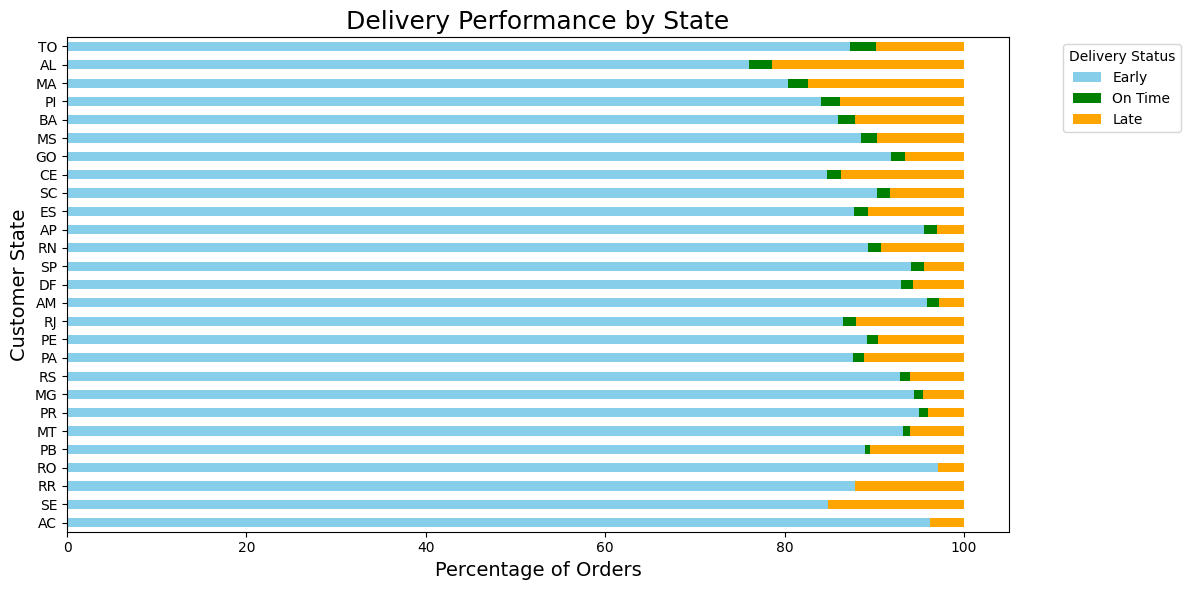

In [68]:
# Pivot data
pivot_df = df.pivot(index='customer_state', columns='delivery_status', values='percentage')

# Ensure columns exist in the desired order
for status in ['Early', 'On Time', 'Late']:
    if status not in pivot_df.columns:
        pivot_df[status] = 0

pivot_df = pivot_df[['Early', 'On Time', 'Late']]

# Fill NaN with 0 and ensure numeric
pivot_df = pivot_df.fillna(0).astype(float)

# Sort by On Time percentage for clarity
pivot_df = pivot_df.sort_values('On Time', ascending=True)

# Horizontal stacked bar chart
pivot_df.plot(kind='barh', stacked=True, figsize=(12, 6), color=['skyblue', 'green', 'orange'])

plt.xlabel('Percentage of Orders', fontsize = 14)
plt.ylabel('Customer State', fontsize = 14)
plt.title('Delivery Performance by State', fontsize = 18)
plt.legend(title='Delivery Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 21. Customer retention rate (repurchase within 6 months)

In [25]:
query = """with a as (
    select c.customer_unique_id, 
           min(o.order_purchase_timestamp) as first_order
    from customers c
    join orders o on c.customer_id = o.customer_id
    group by c.customer_unique_id
), 
b as (
    select distinct a.customer_unique_id
    from a 
    join customers c on c.customer_unique_id = a.customer_unique_id
    join orders o on o.customer_id = c.customer_id
    where o.order_purchase_timestamp > a.first_order
      and o.order_purchase_timestamp < date_add(a.first_order, interval 6 month)
)
select 
    round(count(distinct b.customer_unique_id) * 100.0 / count(distinct a.customer_unique_id), 2) as retention_rate_percentage
from a
left join b on a.customer_unique_id = b.customer_unique_id;"""
cur.execute(query)
data = cur.fetchall()
data

[(Decimal('2.32'),)]

## Key Findings

Going through all the sections above, a few things stood out to me the most:

* Customer retention is really low, only 2.32% of people who ordered once came back and bought again within 6 months. Most customers on this platform are one time buyers, not repeat ones.

* Delivery speed depends a lot on location. Customers in SP get their orders in about 8.7 days on average, while customers in RR wait around 29 days, that is more than 3 times longer for basically the same platform.

* Installments do affect order value. There is a moderate positive correlation (0.57) between the number of installments and the average order value, so people tend to split bigger purchases into more installments instead of paying smaller ones over time.

* Sellers are heavily concentrated in one state. Out of around 3,095 total sellers, close to 60% are based in SP alone, so the seller base is not spread out evenly across Brazil.

* Most orders fall in the medium spend range. 42% of delivered orders land in the 100 to 300 payment range, while high and very high spend orders combined make up only about 10% of all orders, so big ticket purchases are the exception, not the norm.

---
**Rishav Raj**  
Skills: SQL - Python - Power BI - Tableau - MS Excel  
[LinkedIn](https://www.linkedin.com/in/rishav-raj-7a6544362/) | [GitHub](https://github.com/rishav-raj-01)